## Exercice 0. Getting Started: Ring Attractors in 1D

In [2]:
import math
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import convolve1d

Question 1

In [3]:
def mexican_hat_1d(x, A_exc, sigma_exc, A_inh, sigma_inh) : 
    weight = (A_exc*math.exp(-x**2/sigma_exc**2)) - (A_inh*math.exp(-x**2/sigma_inh**2))

    return weight


Question 2

In [4]:
M = 100
A_exc = 0.3
sigma_exc = 5.0
A_inh = 0.2
sigma_inh = 10.0 

#positions of neurons centered around 0 

x_values = np.linspace(-M/2, M/2, M)

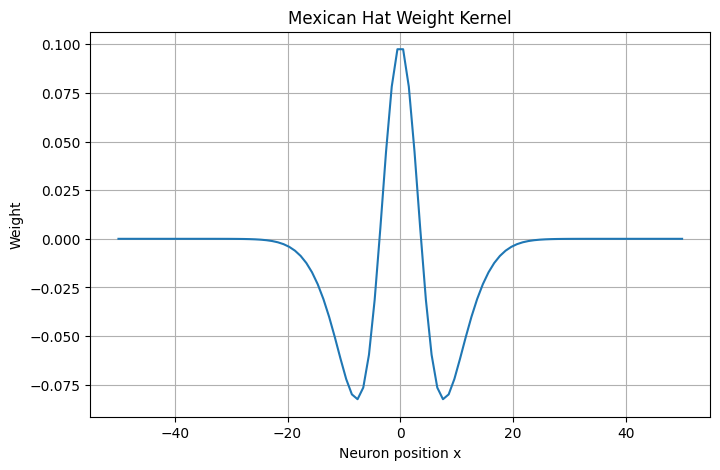

In [5]:
# Weights calculation 

weights = [mexican_hat_1d(x, A_exc, sigma_exc, A_inh, sigma_inh) for x in x_values]

#Plot

plt.figure(figsize=(8,5))
plt.plot(x_values, weights)

plt.title("Mexican Hat Weight Kernel")
plt.xlabel("Neuron position x")
plt.ylabel("Weight")
plt.grid(True)
plt.show()

Question 3

The Mexican hat kernel represents a common feature of cortical connectivity which is local excitation combined with long-range inhibition. Nearby neurons tend to excite each other, while neurons farther away produce inhibitory effects. This organization is frequently observed in cortical neural circuits. 

The kernel is defined as:

$$
w(x)=A_{exc}e^{-x^2/\sigma_{exc}^2}-A_{inh}e^{-x^2/\sigma_{inh}^2}
$$

where:
- $A_{exc}$ and $\sigma_{exc}$ control the strength and spatial range of excitation,
- $A_{inh}$ and $\sigma_{inh}$ control the strength and spatial range of inhibition.

Since: $$\sigma_{inh} > \sigma_{exc}$$ inhibition spreads over a wider region than excitation. 

Biologicaly, this connectivity pattern alows: 
- competition between neurons
- stimulus selection
- contrast enhancement 
- pattern formation
... 

In the plot, the positive central region corresponds to strong local excitation, while the negative surrounding region corresponds to broader inhibition. 

Question 4

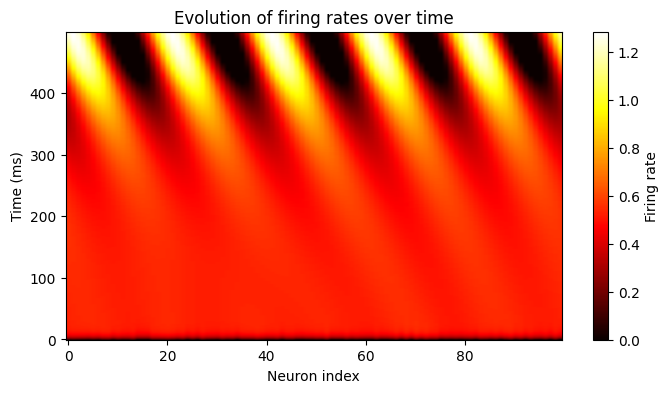

In [20]:
# Simulation parameters

dt = 1.0
T = 500
tau = 10.0
B = 1.0

# Initial potentials 

np.random.seed(0) # change seed for initialization and check behavior

s = np.random.uniform(0, 0.1, M)

# Store firing rates of every neuron over time
r_history = np.zeros((T,M)) 

# Simulation loop 
for t in range(T): 
    #ReLU firing rates over time 
    r = np.maximum(0,s)
    # Store activity
    r_history[t] = r
    # Recurrent input with periodic boundary conditions
    I_rec = convolve1d(r, weights, mode='wrap')
    # Differential equation 
    dsdt = (-s + I_rec + B) / tau
    # Forwars Euler update 
    s = s + dt * dsdt

# Heatmap of firing rates 
plt.figure(figsize=(8,4))

plt.imshow(
    r_history,
    aspect='auto',
    origin='lower',
    cmap='hot'
)

plt.colorbar(label='Firing rate')
plt.xlabel('Neuron index')
plt.ylabel('Time (ms)')
plt.title('Evolution of firing rates over time')

plt.show()

Question 5

The network activity evolves from a random initial condition toward a structured spatial pattern.  
At the beginning of the simulation, the firing rates are weak and irregular because the potentials
\(s(x,0)\) are randomly initialized.

As time progresses, the recurrent connectivity amplifies local activity through short-range excitation,
while long-range inhibition suppresses neighboring regions. This interaction produces localized regions
of high activity that propagate around the ring because of the periodic boundary conditions.

The heatmap shows:
- smooth spatial organization of activity,
- amplification of specific neuronal populations,
- suppression of surrounding neurons due to inhibition.

The dynamics become increasingly structured over time, indicating that the recurrent connectivity
dominates over the initial random fluctuations.

Different seeds produce slightly different early dynamics because the initial perturbations are different. However the global qualitative behavior network remains simila in all cases. 

The network still develops organized activity patterns, excitation and inhibition still create structured bumps of activity, the ring topology remains visible. 

Therefore, the precise trajectory depends somewhat on the initialization, but the overall behavior is
mainly determined by the recurrent Mexican-hat connectivity and not by the exact initial condition.

## Exercice 1. 1D Velocity Integration